# MFA-Modell für Roggenstroh - Modulare Version

## Changelog / Änderungsprotokoll

* **Version:** 1.0
* **Datum:** 14.06.2025
* **Autor:** [JS]
* **Änderungen:**
    * Grundstruktur für modulares Notebook erstellt.
    * Code in Funktionsblöcke unterteilt (Setup, Berechnungen, Visualisierung).

# Section 0: Importing the packages & basic settings translator

In [76]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

# Section 1: Configuration

In [115]:
# ====================================================================
# Section 1: Model Configuration
# All user-defined settings for a scenario run go here.
# ====================================================================

# --- File Paths ---
EXCEL_FILE_PATH = '250616_Template_CS1_=2.xlsx'

# --- Model Scope ---
START_YEAR = 2025
END_YEAR = 2050
ELEMENTS = ['material', 'WC', 'DM', 'CC'] # Elements to be tracked

# --- Dynamic Stock Model (DSM) Parameters ---
# This dictionary holds the parameters for ALL dynamic stocks in the model.
# The key (e.g., 3) is the integer process_id where the stock is located.
# This structure allows for multiple DSMs; just add another process_id as a key.
# In Section 1: Model Configuration
DSM_PARAMS = {
    5: { # Parameter für das Lager im Prozess 3 (MBC_Use-Phase)
        'inflow_split': [0.8, 0.1, 0.1], # 20%, 20%, 60% Aufteilung
        'lifetimes': {
            'Type': 'Normal',
            'Mean': [20, 2, 1],
            'StdDev': [1.0, 0.5, 0.2]
        },
        # NEU: Namen für die Produktkategorien in der Legende der Grafik
        'category_names': ['Insulation Material', 'Panel Board', 'Packaging'] 
    }
}
    # Example for a second dynamic stock in another process (e.g., process 25):
    # 25: {
    #     'lifetimes': {
    #         'Type': 'Lognormal',
    #         'Mean': [50],
    #         'StdDev': [15]
    #     }
    # }

# --- First-Order Model Process (FOMP) Parameters ---
# This dictionary holds parameters for ALL FOMP calculations.
# The key (e.g., 17) is the integer process_id where the decay occurs.
# In Section 1: Model Configuration

FOMP_PARAMS = {
    7: { # Parameter für die Mineralisierung im Prozess 17 (Lithosphere_Stock)
        'outflow_id': 'F_07_08', # NEU: Der exakte Name des Abflusses, der berechnet werden soll
        'f': 0, 
        'k1': 0, 
        'k2': 0.03212
    }
}
    
    # Example for a second FOMP in another process (e.g., process 16):
    # 16: {
    #     'f': 0.1,
    #     'k1': 0.05,
    #     'k2': 0.001
    # }

# Section 2: Function definitions

In [116]:
# ====================================================================
# Section 2: Function Definitions
# ====================================================================

# --- Helper Function 2.1: Define Model Scope & Classifications ---
def define_model_scope(start_year, end_year, elements):
    """
    Defines the temporal and elemental scope of the MFA model.

    Args:
        start_year (int): The first year of the analysis.
        end_year (int): The last year of the analysis.
        elements (list): A list of strings for the elements to be tracked.

    Returns:
        tuple: A tuple containing the ModelClassification dictionary 
               and the IndexTable DataFrame, which are core ODYM objects.
    """
    ModelClassification = {}
    MyYears = list(np.arange(start_year, end_year + 1))
    
    # Define Time and Element Classifications for the ODYM framework
    ModelClassification['Time'] = msc.Classification(Name='Time', Dimension='Time', ID=1, Items=MyYears)
    ModelClassification['Element'] = msc.Classification(Name='Elements', Dimension='Element', ID=2, Items=elements)

    # Create the IndexTable, which ODYM uses for calculations
    IndexTable = pd.DataFrame({
        'Aspect': ['Time', 'Element'],
        'Description': ['Model aspect "time"', 'Model aspect "Element"'],
        'Dimension': ['Time', 'Element'],
        'Classification': [ModelClassification[Aspect] for Aspect in ['Time', 'Element']],
        'IndexLetter': ['t', 'e']
    })
    IndexTable.set_index('Aspect', inplace=True)
    
    print("--> Model scope and classifications defined.")
    return ModelClassification, IndexTable

In [117]:
# --- Helper Function 2.2: Initialize the main MFA System object ---
def initialize_mfa_system(model_classification, index_table):
    """
    Initializes the main MFAsystem object based on the defined scope.

    Args:
        model_classification (dict): The ModelClassification dictionary from define_model_scope.
        index_table (pd.DataFrame): The IndexTable DataFrame from define_model_scope.

    Returns:
        odym.MFAsystem: An empty but structured MFAsystem object.
    """
    # Extract scope details from the input objects
    start_time = model_classification['Time'].Items[0]
    end_time = model_classification['Time'].Items[-1]
    element_items = model_classification['Element'].Items
    
    # Create the main system object using the ODYM class
    MFA_System = msc.MFAsystem(
        Name='RyeStrawMFA', 
        Geogr_Scope='Case_Study_Region', 
        Unit='Mg', 
        ProcessList=[], 
        FlowDict={}, 
        StockDict={},
        ParameterDict={}, 
        Time_Start=start_time, 
        Time_End=end_time, 
        IndexTable=index_table, 
        Elements=element_items
    )
    
    print("--> MFA system object initialized.")
    return MFA_System

In [118]:
# Helper Function 2.3: Load data and define processes and stocks (Updated)
def load_and_define_processes(mfa_system, excel_path):
    """
    Loads all data from the Excel file, treating 'N.A.' as a missing value,
    and populates the ProcessList and StockDict in the MFA system.
    """
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
    
    # Load all sheets, now recognizing "N.A." as a blank cell (NaN)
    input_data = pd.read_excel(
        excel_path, 
        sheet_name=None, 
        header=0, 
        engine='openpyxl',
        na_values=['N.A.', 'NA', 'n/a'] # NEW: This tells pandas to ignore these values
    )
    print(f"--> Excel file '{excel_path}' loaded successfully.")
    
    process_definitions = input_data['2_1_Definition_Processes']
    
    for index, row in process_definitions.iterrows():
        # The 'pd.notna' check now also correctly handles the "N.A." strings
        if pd.notna(row['Name(EN)']):
            process_id = int(row['ID'])
            has_tcs = 'TC' if row['TC?'] == 'Yes' else 'None'
            
            mfa_system.ProcessList.append(
                msc.Process(Name=row['Name(EN)'], ID=process_id, Extensions=has_tcs)
            )
            
            if row['Stock?'] == 'Yes':
                mfa_system.StockDict[f"dS_{process_id}"] = msc.Stock(
                    Name=f"dS_{process_id}", P_Res=process_id, Type=1, Indices='t,e', Values=None
                )
                mfa_system.StockDict[f"S_{process_id}"] = msc.Stock(
                    Name=f"S_{process_id}", P_Res=process_id, Type=0, Indices='t,e', Values=None
                )

    mfa_system.Initialize_StockValues()
    print(f"--> Defined {len(mfa_system.ProcessList)} processes and associated stocks.")
    return mfa_system, input_data

In [119]:
# Helper Function 2.4: Define flows and all model parameters (Final Corrected Version)
def define_flows_and_parameters(mfa_system, all_excel_data, dsm_params_config, fomp_params_config):
    """
    Defines all flows and parameters, including the final calculation of
    elemental compositions for all flows.
    """
    # --- Steps 1 & 2 remain the same: Define structure and add material data ---
    flow_definitions = all_excel_data['1_1_Definition_Flows']
    for index, row in flow_definitions.iterrows():
        if pd.notna(row['Name(EN)']):
            import re
            start_id_str = str(row['Process_ID_O'])
            end_id_str = str(row['Process_ID_I'])
            start_match = re.match(r'(\d+)', start_id_str)
            end_match = re.match(r'(\d+)', end_id_str)
            if start_match and end_match:
                start_id, end_id = int(start_match.group(1)), int(end_match.group(1))
                mfa_system.FlowDict[row['Flow_ID']] = msc.Flow(
                    Name=row['Flow_ID'], P_Start=start_id, P_End=end_id, Indices='t,e', Values=None
                )
    mfa_system.Initialize_FlowValues()
    print("--> Defined flows.")
    
    flow_data = all_excel_data['1_2_Data_Flows']
    for flow_id, flow_obj in mfa_system.FlowDict.items():
        if flow_id in flow_data['Flow_ID'].values:
            flow_time_series = flow_data[flow_data['Flow_ID'] == flow_id]
            if len(flow_time_series) == len(mfa_system.IndexTable.Classification['Time'].Items):
                flow_obj.Values[:, 0] = np.array(flow_time_series['Flow_Py']).ravel()
    print("--> Added numerical data to input flows.")

    # --- Step 3: Define all Parameters ---
    parameter_id_counter = 1
    # Dynamic TCs
    dynamic_tc_sheet = all_excel_data.get('2_5_dynamic_tcs')
    if dynamic_tc_sheet is not None:
        dynamic_tcs = create_dynamic_tc_parameters(dynamic_tc_sheet, mfa_system.IndexTable.Classification['Time'].Items)
        for name, values in dynamic_tcs.items():
            mfa_system.ParameterDict[name] = msc.Parameter(Name=name, ID=parameter_id_counter, Values=values, Unit='1')
            parameter_id_counter += 1
    
    # Elemental Contents
    content_definitions = all_excel_data['1_1_Definition_Flows']
    for index, row in content_definitions.iterrows():
        if pd.notna(row['Flow_ID']) and row['Flow_ID'] in mfa_system.FlowDict:
            for element in ['WC', 'DM', 'CC']:
                if element in row and pd.notna(row[element]):
                    mfa_system.ParameterDict[f"{element}_{row['Flow_ID']}"] = msc.Parameter(
                        Name=f"{element}_{row['Flow_ID']}", ID=parameter_id_counter, Values=row[element], Unit='1'
                    )
                    parameter_id_counter += 1
    
    # DSM Parameters
    for process_id, params in dsm_params_config.items():
        for param_name, value in params['lifetimes'].items():
            mfa_system.ParameterDict[f"dsm_{process_id}_{param_name}"] = msc.Parameter(
                Name=f"dsm_{process_id}_{param_name}", ID=parameter_id_counter, P_Res=process_id, Values=value, Unit='yr'
            )
            parameter_id_counter += 1
            
    print(f"--> Defined {len(mfa_system.ParameterDict)} parameters.")

    # --- NEUER SCHRITT 4: Berechne Elementgehalte für primäre Input-Flüsse ---
    print("--> Calculating elemental composition for primary input flows...")
    for flow in mfa_system.FlowDict.values():
        # Check if the material flow for this flow is already filled
        if np.any(flow.Values[:, 0] != 0):
            # Loop through WC, DM, CC and calculate their values
            for i_elem, element_name in enumerate(mfa_system.Elements[1:], 1):
                param_name = f"{element_name}_{flow.Name}"
                if param_name in mfa_system.ParameterDict:
                    content_value = mfa_system.ParameterDict[param_name].Values
                    flow.Values[:, i_elem] = flow.Values[:, 0] * content_value
    
    # --- Final Consistency Check ---
    mfa_system.Consistency_Check()
    print("--> System setup is complete and ready for calculations!")
    
    return mfa_system, all_excel_data

In [120]:
# Helper Function 2.5: Create dynamic TC time series from long table with interpolation
def create_dynamic_tc_parameters(dynamic_tc_data, time_vector):
    """
    Generates time series for TCs by reading a long data table and interpolating
    between the defined data points for each year in the model scope.

    Args:
        dynamic_tc_data (pd.DataFrame): DataFrame loaded from the dynamic TCs sheet.
        time_vector (list): The list of years for the analysis.

    Returns:
        dict: A dictionary of TC names and their complete time series arrays.
    """
    print("--> Generating dynamic TC time series via interpolation...")
    dynamic_tc_dict = {}
    
    # Get a list of all unique TC_IDs from the input sheet
    if 'TC_ID' not in dynamic_tc_data.columns:
        print("--> Warning: 'TC_ID' column not found in dynamic TCs sheet. Skipping.")
        return {}
        
    unique_tc_ids = dynamic_tc_data['TC_ID'].unique()
    
    for tc_id in unique_tc_ids:
        if pd.isna(tc_id):
            continue

        # Filter the dataframe for the current TC_ID
        tc_points = dynamic_tc_data[dynamic_tc_data['TC_ID'] == tc_id]
        
        # Create a pandas Series with the defined data points, using 'Year' as the index
        ts = pd.Series(tc_points['Value'].values, index=tc_points['Year'])
        
        # Create a complete time series by reindexing with all model years
        ts_full = ts.reindex(time_vector)
        
        # Interpolate the missing values (e.g., linear) and fill first/last values
        ts_interpolated = ts_full.interpolate(method='linear', limit_direction='both')
        
        # Store the final numpy array in our dictionary
        dynamic_tc_dict[tc_id] = ts_interpolated.to_numpy()

    print(f"--> Generated {len(dynamic_tc_dict)} dynamic TC parameter(s).")
    return dynamic_tc_dict

In [121]:
# Helper Function 2.6: Calculate flows based on Transfer Coefficients (TCs)
def calculate_tc_flows(mfa_system, max_iterations=10):
    """
    Iteratively calculates flows where inputs and TCs are known.
    It loops multiple times to solve chains of dependent flows.
    """
    print("--> Calculating TC-based flows...")
    for i in range(max_iterations):
        calculated_a_flow = False
        for flow in mfa_system.FlowDict.values():
            # Check if this flow has already been calculated (based on material value)
            if np.all(flow.Values[:, 0] == 0): 
                param_name = f"TC_{'_'.join(flow.Name.split('_')[1:3])}"
                
                # Check if a TC is defined for this flow
                if param_name in mfa_system.ParameterDict:
                    # Find all input flows to the process where this flow starts
                    input_flows = [f for f in mfa_system.FlowDict.values() if f.P_End == flow.P_Start]
                    
                    # Check if all input flows are known
                    if all(np.any(f.Values != 0) or f.P_Start == 0 for f in input_flows):
                        sum_input_flows = sum(f.Values[:, 0] for f in input_flows)
                        tc_value = mfa_system.ParameterDict[param_name].Values
                        
                        # Calculate the 'material' flow
                        flow.Values[:, 0] = sum_input_flows * tc_value
                        calculated_a_flow = True
                        
                        # Calculate the elemental contents based on the material flow
                        for i_elem, element in enumerate(mfa_system.Elements[1:], 1):
                            content_param_name = f"{element}_{flow.Name}"
                            if content_param_name in mfa_system.ParameterDict:
                                content_value = mfa_system.ParameterDict[content_param_name].Values
                                flow.Values[:, i_elem] = flow.Values[:, 0] * content_value

        if not calculated_a_flow:
            break
            
    print("--> TC-based flow calculation finished.")
    return mfa_system

In [122]:
# Helper Function 2.7: Calculate dynamic stocks for specified processes (Final Corrected Version)
def calculate_dynamic_stock(mfa_system, dsm_params_config):
    """
    Calculates stocks and outflows for all processes defined with DSM parameters,
    including logic for multiple product categories and safeguards against zero-inflows.
    """
    print("--> Calculating dynamic stocks...")
    time_vector = np.array(mfa_system.IndexTable.Classification['Time'].Items)
    
    for process_id, params in dsm_params_config.items():
        print(f"    ... running DSM for process {process_id}")
        
        inflow_flow_name = next((f.Name for f in mfa_system.FlowDict.values() if f.P_End == process_id), None)
        if not inflow_flow_name:
            print(f"Warning: No inflow found for dynamic stock process {process_id}. Skipping.")
            continue
        
        inflow_values = mfa_system.FlowDict[inflow_flow_name].Values
        
        outflow_flow_name = next((f.Name for f in mfa_system.FlowDict.values() if f.P_Start == process_id), None)
        if not outflow_flow_name:
            print(f"Warning: No outflow found for dynamic stock process {process_id}. Skipping.")
            continue
            
        lt_params = params.get('lifetimes', {})
        inflow_split = params.get('inflow_split', [1.0])
        
        outflow_total_material = np.zeros(len(time_vector))
        stock_total_material = np.zeros(len(time_vector))

        # Run DSM for each product category
        for i in range(len(inflow_split)):
            split_factor = inflow_split[i]
            inflow_category = inflow_values[:, 0] * split_factor
            
            # --- NEW SAFEGUARD ---
            # Only run the calculation if there is actually an inflow to this category
            if np.sum(inflow_category) > 0:
                dsm_model = dsm.DynamicStockModel(
                    t=time_vector,
                    i=inflow_category,
                    lt={'Type': lt_params.get('Type'), 'Mean': [lt_params.get('Mean')[i]], 'StdDev': [lt_params.get('StdDev')[i]]}
                )
                
                s_c = dsm_model.compute_s_c_inflow_driven()
                
                # CORRECTED CALL: The function expects no arguments
                o_c = dsm_model.compute_o_c_from_s_c()
                
                # Additional check to ensure o_c is not None before summing
                if o_c is not None:
                    outflow_total_material += o_c.sum(axis=1)
                    stock_total_material += s_c.sum(axis=1)

        # --- Update the main MFA system object ---
        mfa_system.FlowDict[outflow_flow_name].Values[:, 0] = outflow_total_material
        
        # Calculate and assign elemental compositions for the outflow
        for elem_idx in range(1, inflow_values.shape[1]):
            inflow_material = inflow_values[:, 0]
            composition_factor = np.divide(inflow_values[:, elem_idx], inflow_material, out=np.zeros_like(inflow_material), where=inflow_material!=0)
            mfa_system.FlowDict[outflow_flow_name].Values[:, elem_idx] = outflow_total_material * composition_factor
        
        # Calculate and assign the total stock and stock change
        dS_values = inflow_values - mfa_system.FlowDict[outflow_flow_name].Values
        mfa_system.StockDict[f'dS_{process_id}'].Values = dS_values
        
        # For the absolute stock, we also need to handle the elemental composition
        mfa_system.StockDict[f'S_{process_id}'].Values[:, 0] = stock_total_material
        for elem_idx in range(1, inflow_values.shape[1]):
             inflow_material = inflow_values[:, 0]
             composition_factor = np.divide(inflow_values[:, elem_idx], inflow_material, out=np.zeros_like(inflow_material), where=inflow_material!=0)
             mfa_system.StockDict[f'S_{process_id}'].Values[:, elem_idx] = stock_total_material * composition_factor
            
    print("--> Dynamic stock calculation finished.")
    return mfa_system

In [123]:
# Helper Function 2.7: Calculate final stock changes and balances
def calculate_final_balances(mfa_system):
    """
    Calculates the stock changes (dS) and absolute stocks (S) for all processes.
    This should be called after all flows have been calculated.

    Args:
        mfa_system (odym.MFAsystem): The MFA system object with calculated flows.

    Returns:
        odym.MFAsystem: The MFA system object with calculated stocks.
    """
    print("--> Calculating final stock balances...")
    for process in mfa_system.ProcessList:
        # Check if a stock is associated with this process
        if f"S_{process.ID}" in mfa_system.StockDict:
            
            # Find all input and output flows for this process
            input_flows = [f.Values for f in mfa_system.FlowDict.values() if f.P_End == process.ID]
            output_flows = [f.Values for f in mfa_system.FlowDict.values() if f.P_Start == process.ID]
            
            sum_input_flows = sum(input_flows) if input_flows else 0
            sum_output_flows = sum(output_flows) if output_flows else 0
            
            # Calculate stock change (dS) and absolute stock (S)
            dS_values = sum_input_flows - sum_output_flows
            mfa_system.StockDict[f"dS_{process.ID}"].Values = dS_values
            mfa_system.StockDict[f"S_{process.ID}"].Values = dS_values.cumsum(axis=0)
            
    print("--> Stock balance calculation finished.")
    return mfa_system

### Erklärung: First-Order Model Process (FOMP)

Ein **First-Order Model Process** (Modellprozess erster Ordnung) wird verwendet, um Prozesse zu simulieren, bei denen die Rate des Austrags (z.B. Abbau, Mineralisierung, Emission) direkt von der Menge des im System vorhandenen Materials (dem Lagerbestand) abhängt.

**Analogie:** Man kann es sich wie eine Badewanne mit offenem Abfluss vorstellen. Je mehr Wasser (Lager) in der Wanne ist, desto höher ist der Druck und desto schneller fließt das Wasser ab (Abfluss). Der Abfluss verlangsamt sich, wenn das Lager kleiner wird.

In diesem Modell wird der FOMP verwendet, um die **Mineralisierung von Biokohle im Boden** (Prozess 17, `Lithosphere_Stock`) über die Zeit zu simulieren. Die vereinfachte Formel, die wir verwenden, lautet:

`Mineralisierungsrate(t) = Lager(t-1) * k`

* `Lager(t-1)` ist der Kohlenstoffbestand im Boden aus dem Vorjahr.
* `k` ist die **Abbaurate** oder **Zerfallskonstante**, die angibt, welcher prozentuale Anteil des Lagerbestands pro Jahr abgebaut wird.

Ein kleiner `k`-Wert bedeutet einen langsamen Abbau und eine lange Verweildauer im Boden, was für die Kohlenstoffsequestrierung erwünscht ist.


* Material	Zerfallskonstante k (pro Jahr)	Ungefähre Halbwertszeit	Anmerkung
* Stroh (unbehandelt)	0.1 - 0.5	1.5 - 7 Jahre	Zersetzt sich relativ schnell im Boden.
* Wurzelmasse	0.05 - 0.2	3.5 - 14 Jahre	Etwas stabiler als oberirdisches Stroh.
* Biokohle (labil)	0.01 - 0.05	14 - 70 Jahre	Der Anteil der Biokohle, der sich schneller zersetzt. Dein Wert von 0.032 passt gut in diese Kategorie.
* Biokohle (stabil)	0.0001 - 0.001	700 - 7000 Jahre	Der Großteil der Biokohle ist extrem langlebig und trägt zur langfristigen Kohlenstoffspeicherung bei.


In [124]:
# --- Helper Function 2.8: Calculate First-Order Model Processes (FOMP) (Robust Version) ---
def calculate_fomp(mfa_system, fomp_params_config):
    """
    Calculates stock-dependent outflows for all processes defined with FOMP parameters.
    """
    print("--> Calculating First-Order Model Processes (FOMP)...")
    time_vector = mfa_system.IndexTable.Classification['Time'].Items
    num_years = len(time_vector)
    
    for process_id, params in fomp_params_config.items():
        print(f"    ... running FOMP for process {process_id}")
        
        # Get the specific outflow for this FOMP process from the config
        outflow_flow_name = params.get('outflow_id')
        if not outflow_flow_name or outflow_flow_name not in mfa_system.FlowDict:
            print(f"Warning: Outflow '{outflow_flow_name}' for FOMP process {process_id} not found. Skipping.")
            continue
        
        f, k1, k2 = params.get('f', 0), params.get('k1', 0), params.get('k2', 0)
        inflow_values = sum(flow.Values for flow in mfa_system.FlowDict.values() if flow.P_End == process_id)
        
        stock_s, stock_ds = mfa_system.StockDict.get(f"S_{process_id}"), mfa_system.StockDict.get(f"dS_{process_id}")
        
        new_outflow_values = np.zeros_like(inflow_values)
        new_stock_values = np.zeros_like(inflow_values)
        
        for t in range(num_years):
            stock_t_minus_1 = new_stock_values[t-1, :] if t > 0 else 0
            outflow_t = (inflow_values[t, :] * f) + (stock_t_minus_1 * k1) + (inflow_values[t, :] * k2)
            new_outflow_values[t, :] = outflow_t
            stock_t = stock_t_minus_1 + inflow_values[t, :] - outflow_t
            new_stock_values[t, :] = stock_t

        # Update the MFA system object with the calculated values
        mfa_system.FlowDict[outflow_flow_name].Values = new_outflow_values
        stock_s.Values = new_stock_values
        stock_ds.Values = inflow_values - new_outflow_values

    print("--> FOMP calculation finished.")
    return mfa_system

In [125]:
# Main Calculation Function (Wrapper) - Updated with FOMP
def run_mfa_calculation(mfa_system_configured):
    """
    Orchestrates the full MFA calculation process, including DSM and FOMP.
    """
    import copy
    mfa_system = copy.deepcopy(mfa_system_configured)
    
    # === Step 1: Calculate initial flows ===
    print("--> Calculation Step 1: Calculating initial flows...")
    mfa_system = calculate_tc_flows(mfa_system)
    
    # === Step 2: Run Dynamic Stock Model ===
    print("--> Calculation Step 2: Running Dynamic Stock Model...")
    mfa_system = calculate_dynamic_stock(mfa_system, DSM_PARAMS)
    
    # === Step 3: Calculate remaining flows ===
    print("--> Calculation Step 3: Calculating remaining flows...")
    mfa_system = calculate_tc_flows(mfa_system)

    # === Step 4: Run First-Order Model Process (FOMP) ===
    print("--> Calculation Step 4: Running FOMP...")
    mfa_system = calculate_fomp(mfa_system, FOMP_PARAMS)
    
    # === Step 5: Calculate all remaining stock balances ===
    print("--> Calculation Step 5: Calculating all stock balances...")
    mfa_system = calculate_final_balances(mfa_system)
    
    print("\n--> MFA calculation process finished.")
    return mfa_system

# Section 3: Main workflow (execution)

In [126]:

# ====================================================================
# Section 3: Main Execution / Workflow (Corrected Version)
# ====================================================================

# --- 1. Define Model Scope ---
# We call our new function and pass the parameters from the configuration block
model_classification, index_table = define_model_scope(START_YEAR, END_YEAR, ELEMENTS)

# --- 2. Initialize the MFA System Object ---
# The output of the first function is the input for this one
my_mfa_system = initialize_mfa_system(model_classification, index_table)

# --- 3. Load Data and Define Processes/Stocks ---
# The mfa_system object is passed in and gets modified by the function.
# We also receive all excel data to use it in the next steps.
my_mfa_system, all_excel_data = load_and_define_processes(my_mfa_system, EXCEL_FILE_PATH)

# --- 4. Define Flows and Parameters ---
# This function completes the setup of the system object.
# This is the correct call that unpacks the tuple.
my_mfa_system_configured, _ = define_flows_and_parameters(my_mfa_system, all_excel_data, DSM_PARAMS, FOMP_PARAMS)

# --- 5. Calculation Phase ---
print("\nRunning MFA calculations...")
my_mfa_system_with_results = run_mfa_calculation(my_mfa_system_configured)
print("Calculation complete.")

# --- 6. Display final mass balance (optional) ---
balance = my_mfa_system_with_results.MassBalance()
print("\nFinal Mass Balance Check (Sum of absolute errors per process):")
print(np.abs(balance).sum(axis=0).sum(axis=1))

print("\n✅ System setup is complete and ready for calculations!")

--> Model scope and classifications defined.
--> MFA system object initialized.
--> Excel file '250616_Template_CS1_=2.xlsx' loaded successfully.
--> Defined 11 processes and associated stocks.
--> Defined flows.
--> Added numerical data to input flows.
--> Generating dynamic TC time series via interpolation...
--> Generated 11 dynamic TC parameter(s).
--> Defined 77 parameters.
--> Calculating elemental composition for primary input flows...
--> System setup is complete and ready for calculations!

Running MFA calculations...
--> Calculation Step 1: Calculating initial flows...
--> Calculating TC-based flows...
--> TC-based flow calculation finished.
--> Calculation Step 2: Running Dynamic Stock Model...
--> Calculating dynamic stocks...
    ... running DSM for process 5
--> Dynamic stock calculation finished.
--> Calculation Step 3: Calculating remaining flows...
--> Calculating TC-based flows...
--> TC-based flow calculation finished.
--> Calculation Step 4: Running FOMP...
--> Calc

# Section 4: Results and visualization

In [127]:
# --- Helper Function 4.1: Create an interactive Sankey plot (Corrected) ---
def plot_interactive_sankey(mfa_system_results):
    """
    Generates and displays an interactive Sankey diagram with widgets to select
    the year, element, and processes to display.
    """
    import plotly.graph_objects as go
    from ipywidgets import interact, IntSlider, Dropdown, SelectMultiple

    all_process_names = [p.Name for p in mfa_system_results.ProcessList]
    all_flows = list(mfa_system_results.FlowDict.values())
    time_items = mfa_system_results.IndexTable.Classification['Time'].Items
    element_items = mfa_system_results.Elements

    # This inner function is called whenever a widget value changes
    def update_and_show_sankey(year, element, processes_to_show):
        if not processes_to_show:
            print("Please select at least one process to display.")
            return

        label_map = {p.ID: i for i, p in enumerate(mfa_system_results.ProcessList) if p.Name in processes_to_show}
        filtered_labels = list(processes_to_show)
        filtered_flows = [f for f in all_flows if f.P_Start in label_map and f.P_End in label_map]
        
        year_index = time_items.index(year)
        element_index = element_items.index(element)
        new_values = [f.Values[year_index, element_index] for f in filtered_flows]
        
        # Create the figure from scratch on each update
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=20,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=filtered_labels,
                color="blue"
            ),
            link=dict(
                source=[label_map[f.P_Start] for f in filtered_flows],
                target=[label_map[f.P_End] for f in filtered_flows],
                value=new_values
            )
        )])
        fig.update_layout(title_text=f"MFA Sankey for {element.upper()} in {year}", font_size=12, height=700)
        fig.show()

    # Create the interactive widgets
    year_slider = IntSlider(min=time_items[0], max=time_items[-1], step=1, value=time_items[0], description='Year')
    element_dropdown = Dropdown(options=element_items, value=element_items[0], description='Element')
    process_selector = SelectMultiple(options=all_process_names, value=list(all_process_names), description='Processes', rows=8)
    
    # Link widgets to the update function
    interact(update_and_show_sankey, year=year_slider, element=element_dropdown, processes_to_show=process_selector);

In [128]:
# --- Helper Function 4.2: Plot Mass Balances with Process Selection (Corrected) ---
def plot_process_balances(mfa_system_results, year, element, processes_to_show):
    """
    Generates a grouped bar chart to visualize the mass balance for a specific year,
    element, and selected processes. This function is designed to be called by ipywidgets.interact.
    """
    import plotly.graph_objects as go
    
    # If no processes are selected, don't show a plot
    if not processes_to_show:
        print("Please select at least one process to display.")
        return

    time_items = mfa_system_results.IndexTable.Classification['Time'].Items
    element_items = mfa_system_results.Elements
    
    year_index = time_items.index(year)
    element_index = element_items.index(element)
    
    plot_labels, inflows_sum, outflows_plus_stock_sum = [], [], []

    for p in mfa_system_results.ProcessList:
        if p.Name in processes_to_show:
            plot_labels.append(p.Name)
            # Sum of inflows for the process
            in_val = sum(f.Values[year_index, element_index] for f in mfa_system_results.FlowDict.values() if f.P_End == p.ID)
            # Sum of outflows for the process
            out_val = sum(f.Values[year_index, element_index] for f in mfa_system_results.FlowDict.values() if f.P_Start == p.ID)
            # Stock change for the process
            ds_val = mfa_system_results.StockDict.get(f'dS_{p.ID}', None)
            ds_sum = ds_val.Values[year_index, element_index] if ds_val is not None else 0
            
            inflows_sum.append(in_val)
            outflows_plus_stock_sum.append(out_val + ds_sum)
    
    # Create the figure object
    fig = go.Figure(data=[
        go.Bar(name='Inflows', x=plot_labels, y=inflows_sum, marker_color='green'),
        go.Bar(name='Outflows + Stock Change', x=plot_labels, y=outflows_plus_stock_sum, marker_color='red')
    ])
    fig.update_layout(
        barmode='group',
        title=f"Process Mass Balance for {element.upper()} in {year}",
        yaxis_title="Mass in Mg"
    )
    fig.show()

In [129]:
# --- Helper Function 4.3: Plot Inflow, Stock, and Outflow (Final Interactive Version) ---
def plot_process_dynamics(mfa_system_results):
    """
    Creates three side-by-side line charts showing the dynamics of 
    Inflow, Stock, and Outflow over time for a selected process and element.
    """
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    from ipywidgets import interact, Dropdown

    # Create a mapping from process names to IDs for the dropdown
    process_options = {p.Name: p.ID for p in mfa_system_results.ProcessList if f"S_{p.ID}" in mfa_system_results.StockDict}
    if not process_options:
        print("No processes with stocks found to plot.")
        return
        
    time_axis = mfa_system_results.IndexTable.Classification['Time'].Items
    element_items = mfa_system_results.Elements
    
    # Use FigureWidget for efficient updates
    fig = go.FigureWidget(make_subplots(rows=1, cols=3, subplot_titles=("Total Inflow", "Absolute Stock (S)", "Total Outflow")))

    def update_plot(process_name, element):
        pid = process_options[process_name]
        element_index = element_items.index(element)

        # Calculate time series data based on selection
        inflow_ts = sum(f.Values[:, element_index] for f in mfa_system_results.FlowDict.values() if f.P_End == pid)
        stock_ts = mfa_system_results.StockDict[f'S_{pid}'].Values[:, element_index]
        outflow_ts = sum(f.Values[:, element_index] for f in mfa_system_results.FlowDict.values() if f.P_Start == pid)
        
        # Use batch_update to efficiently update the figure's data
        with fig.batch_update():
            fig.data = [] # Clear existing traces
            fig.add_trace(go.Scatter(x=time_axis, y=inflow_ts, mode='lines', name='Inflow'), row=1, col=1)
            fig.add_trace(go.Scatter(x=time_axis, y=stock_ts, mode='lines', name='Stock'), row=1, col=2)
            fig.add_trace(go.Scatter(x=time_axis, y=outflow_ts, mode='lines', name='Outflow'), row=1, col=3)
            
            title_text = f"Dynamics for Process: '{process_name}' | Element: {element.upper()}"
            fig.update_layout(title_text=title_text, height=400, showlegend=False)
            fig.update_xaxes(title_text="Year")
            fig.update_yaxes(title_text="Mass [Mg]", row=1, col=1)

    # Create widgets for interaction
    process_dropdown = Dropdown(options=list(process_options.keys()), description='Process:')
    element_dropdown = Dropdown(options=element_items, value=element_items[0], description='Element:')
    
    interact(update_plot, process_name=process_dropdown, element=element_dropdown)
    display(fig)

In [130]:
# --- Helper Function 4.4: Plot dynamic stock composition (Final Interactive Version) ---
def plot_dynamic_stock_composition(mfa_system_results, dsm_params_config):
    """
    Creates an interactive stacked chart showing the stock composition over time.
    Includes widgets for process, element, and chart type selection.
    """
    import plotly.graph_objects as go
    from ipywidgets import interact, Dropdown, Checkbox

    # Create a mapping of process names to IDs for the dropdown
    process_options = {
        p.Name: p.ID 
        for p in mfa_system_results.ProcessList 
        if p.ID in dsm_params_config
    }
    if not process_options:
        print("No processes with DSM parameters found to plot.")
        return
        
    element_items = mfa_system_results.Elements
    time_axis = mfa_system_results.IndexTable.Classification['Time'].Items
    
    # Use FigureWidget for efficient interactive updates
    fig = go.FigureWidget()

    def update_plot(process_name, element, show_as_bars):
        process_id = process_options[process_name]
        params = dsm_params_config.get(process_id, {})
        element_index = element_items.index(element)

        # Re-calculate the stock composition for the selected element
        inflow_flow_name = next((f.Name for f in mfa_system_results.FlowDict.values() if f.P_End == process_id), None)
        inflow_values = mfa_system_results.FlowDict[inflow_flow_name].Values
        
        lt_params = params.get('lifetimes', {})
        inflow_split = params.get('inflow_split', [1.0])
        mean_lifetimes = lt_params.get('Mean', [])
        
        # Create enhanced legend labels with lifetime information
        category_names_orig = params.get('category_names', [])
        category_labels = [f"{name} ({lt} yrs)" for name, lt in zip(category_names_orig, mean_lifetimes)]
        
        stock_by_category_ts = []
        for i in range(len(inflow_split)):
            inflow_category_material = inflow_values[:, 0] * inflow_split[i]
            dsm_model = dsm.DynamicStockModel(
                t=np.array(time_axis), i=inflow_category_material,
                lt={'Type': lt_params.get('Type'), 'Mean': [mean_lifetimes[i]], 'StdDev': [lt_params.get('StdDev')[i]]}
            )
            s_c = dsm_model.compute_s_c_inflow_driven()
            
            # Calculate composition factor to apply to the stock
            inflow_material = inflow_values[:, 0]
            composition_factor = np.divide(inflow_values[:, element_index], inflow_material, out=np.zeros_like(inflow_material), where=inflow_material!=0)
            
            stock_by_category_ts.append(s_c.sum(axis=1) * composition_factor)

        # Use batch_update to efficiently update the figure
        with fig.batch_update():
            fig.data = [] # Clear previous traces
            chart_type = go.Bar if show_as_bars else go.Scatter
            
            for i in range(len(stock_by_category_ts)):
                trace_props = dict(x=time_axis, y=stock_by_category_ts[i], name=category_labels[i], hoverinfo='x+y')
                if not show_as_bars:
                    trace_props.update(mode='lines', line=dict(width=0.5), stackgroup='one')
                
                fig.add_trace(chart_type(**trace_props))

            # Update layout and title dynamically
            fig.update_layout(
                barmode='stack' if show_as_bars else None,
                title=f"Dynamic Stock Composition for Process: '{process_name}' ({element.upper()})",
                xaxis_title="Year", yaxis_title=f"Stock in Mg"
            )

    # Create widgets for interaction
    process_dropdown = Dropdown(options=list(process_options.keys()), description='Process:')
    element_dropdown = Dropdown(options=element_items, value=element_items[0], description='Element:')
    chart_type_checkbox = Checkbox(value=False, description='Show as Bar Chart')
    
    interact(update_plot, process_name=process_dropdown, element=element_dropdown, show_as_bars=chart_type_checkbox)
    display(fig)

In [131]:
# --- Helper Function 4.5: Plot the dynamics of a FOMP process ---
def plot_fomp_dynamics(mfa_system_results, fomp_params_config):
    """
    Creates side-by-side line charts for Inflow, Stock, and Outflow
    for a process calculated with FOMP. Includes interactive widgets.
    """
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    from ipywidgets import interact, Dropdown

    # Create a mapping of process names to IDs for the dropdown, only for FOMP processes
    process_options = {
        p.Name: p.ID 
        for p in mfa_system_results.ProcessList 
        if p.ID in fomp_params_config
    }
    if not process_options:
        print("No processes with FOMP parameters are defined in the configuration.")
        return
        
    element_items = mfa_system_results.Elements
    time_axis = mfa_system_results.IndexTable.Classification['Time'].Items
    
    fig = go.FigureWidget(make_subplots(rows=1, cols=3, subplot_titles=("Total Inflow", "Absolute Stock (S)", "Outflow (Mineralization)")))

    def update_plot(process_name, element):
        pid = process_options[process_name]
        element_index = element_items.index(element)

        # Get the time series data for the selected process
        inflow_ts = sum(f.Values[:, element_index] for f in mfa_system_results.FlowDict.values() if f.P_End == pid)
        stock_ts = mfa_system_results.StockDict.get(f'S_{pid}').Values[:, element_index]
        outflow_ts = sum(f.Values[:, element_index] for f in mfa_system_results.FlowDict.values() if f.P_Start == pid)
        
        with fig.batch_update():
            fig.data = [] # Clear existing data
            fig.add_trace(go.Scatter(x=time_axis, y=inflow_ts, mode='lines', name='Inflow'), row=1, col=1)
            fig.add_trace(go.Scatter(x=time_axis, y=stock_ts, mode='lines', name='Stock'), row=1, col=2)
            fig.add_trace(go.Scatter(x=time_axis, y=outflow_ts, mode='lines', name='Outflow'), row=1, col=3)
            
            title_text = f"FOMP Dynamics for Process: '{process_name}' | Element: {element.upper()}"
            fig.update_layout(title_text=title_text, height=400, showlegend=False)
            fig.update_xaxes(title_text="Year")
            fig.update_yaxes(title_text="Mass [Mg]", row=1, col=1)

    # Create widgets for interaction
    process_dropdown = Dropdown(options=list(process_options.keys()), description='Process:')
    element_dropdown = Dropdown(options=element_items, value=element_items[0], description='Element:')
    
    interact(update_plot, process_name=process_dropdown, element=element_dropdown)
    display(fig)

Displaying interactive Sankey diagram:


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…


Displaying Mass Balance Check:


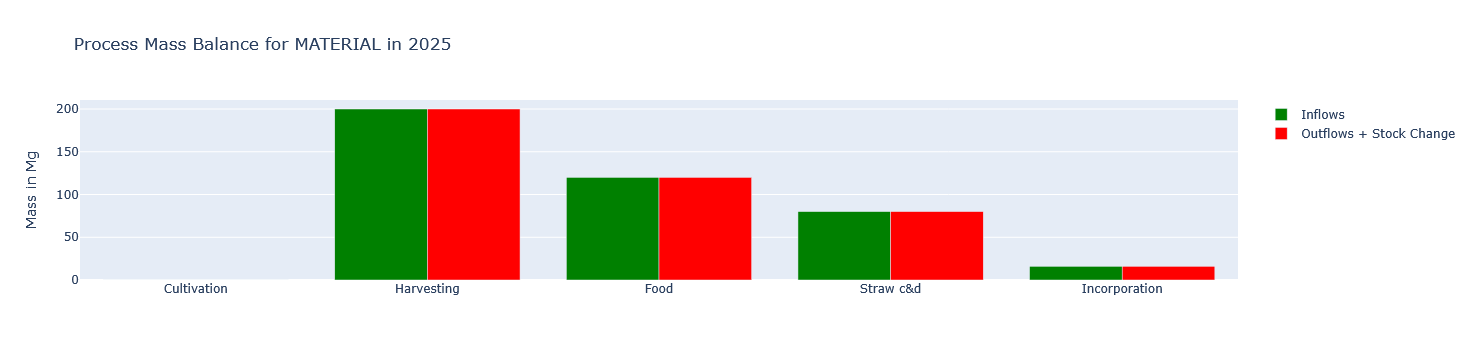


Displaying Inflow-Stock-Outflow Dynamics:


interactive(children=(Dropdown(description='Process:', options=('Cultivation', 'Harvesting', 'Food', 'Straw c&…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '448c0768-e476-47c2-8567-6bd7b5ba0743',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                          0., 0., 0., 0., 0., 0., 0., 0.]),
              'yaxis': 'y'},
             {'mode': 'lines',
              'name': 'Stock',
              'type': 'scatter',
              'uid': '2b65bb7a-14fe-48e6-b554-f39f8ba73649',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 


Displaying Dynamic Stock Composition:


interactive(children=(Dropdown(description='Process:', options=('Composting',), value='Composting'), Dropdown(…

FigureWidget({
    'data': [{'hoverinfo': 'x+y',
              'line': {'width': 0.5},
              'mode': 'lines',
              'name': 'Insulation Material (20 yrs)',
              'stackgroup': 'one',
              'type': 'scatter',
              'uid': '2ebb868e-76ff-4471-b8b5-52ce45f1094e',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': array([ 25.6       ,  48.704     ,  69.44      ,  87.936     , 104.32      ,
                          118.72      , 131.264     , 142.08      , 151.296     , 159.04      ,
                          165.44      , 165.8664    , 176.6184    , 189.6904    , 205.17839997,
                          223.17839264, 243.78558257, 267.06310492, 292.59614653, 317.60262446,
                          337.25559152, 349.39473631, 360.0673097 , 372.43616388, 386.94372522,
  


Displaying FOMP Dynamics (once calculated):


interactive(children=(Dropdown(description='Process:', options=('Lithosphere',), value='Lithosphere'), Dropdow…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '2b3ab5f6-77ca-4cb9-b190-8984c31ce74b',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': array([1.02265259e-04, 1.67279045e+00, 4.63689158e+00, 5.70445668e+00,
                          5.19261830e+00, 4.63273004e+00, 4.10473004e+00, 3.60873004e+00,
                          3.14473004e+00, 2.71273004e+00, 2.31273004e+00, 1.94471104e+00,
                          1.29789613e+00, 1.15850093e+00, 2.21124969e+00, 3.25154788e+00,
                          3.87932552e+00, 4.54102519e+00, 5.73750592e+00, 9.83606959e+00,
                          1.88815805e+01, 2.71193904e+01, 2.91321799e+01, 2.76226258e+01,
                          2.54924268e+01, 2

In [132]:
# ====================================================================
# Section 4: Results & Visualization
# ====================================================================

# --- 4.1 Interactive Sankey Diagram ---
print("Displaying interactive Sankey diagram:")
# This will display the Sankey with a year slider and element dropdown
plot_interactive_sankey(my_mfa_system_with_results)

# --- 4.2 Mass Balance Check ---
# This will display the grouped bar chart with interactive widgets
print("\nDisplaying Mass Balance Check:")
plot_process_balances(my_mfa_system_with_results, year=START_YEAR, element=ELEMENTS[0], processes_to_show= [p.Name for p in my_mfa_system_with_results.ProcessList][:5])


# --- 4.3 Process Dynamics Plot ---
print("\nDisplaying Inflow-Stock-Outflow Dynamics:")
# The function now creates its own widgets, so we just call it directly.
plot_process_dynamics(my_mfa_system_with_results)

# In Section 4.4
print("\nDisplaying Dynamic Stock Composition:")
plot_dynamic_stock_composition(my_mfa_system_with_results, DSM_PARAMS)

# --- 4.5 FOMP Dynamics Plot ---
print("\nDisplaying FOMP Dynamics (once calculated):")
plot_fomp_dynamics(my_mfa_system_with_results, FOMP_PARAMS)


# Section 5: Export Results

In [133]:
# ====================================================================
# Section 5: Export Results
# ====================================================================

def export_results_to_excel(mfa_system_results, output_filename="mfa_results.xlsx"):
    """
    Exports all calculated flows and stocks into a single Excel file with multiple sheets.
    """
    print(f"\n--> Exporting results to '{output_filename}'...")
    
    time_index = mfa_system_results.IndexTable.Classification['Time'].Items
    elements = mfa_system_results.Elements
    
    with pd.ExcelWriter(output_filename) as writer:
        # --- Export Flows ---
        flow_data_rows = []
        for name, flow_obj in mfa_system_results.FlowDict.items():
            for i, year in enumerate(time_index):
                row = {'Flow_ID': name, 'Year': year}
                for j, element in enumerate(elements):
                    row[element] = flow_obj.Values[i, j]
                flow_data_rows.append(row)
        df_flows = pd.DataFrame(flow_data_rows)
        df_flows.to_excel(writer, sheet_name='Flows_ts', index=False)
        
        # --- Export Stocks ---
        stock_data_rows = []
        for name, stock_obj in mfa_system_results.StockDict.items():
            for i, year in enumerate(time_index):
                row = {'Stock_ID': name, 'Year': year}
                for j, element in enumerate(elements):
                    row[element] = stock_obj.Values[i, j]
                stock_data_rows.append(row)
        df_stocks = pd.DataFrame(stock_data_rows)
        df_stocks.to_excel(writer, sheet_name='Stocks_ts', index=False)
        
    print("--> Export complete.")

In [134]:
# ====================================================================
# Section 5: Export Results
# ====================================================================

# Call the export function
export_results_to_excel(my_mfa_system_with_results, output_filename="rye_mfa_results_v1.xlsx")


--> Exporting results to 'rye_mfa_results_v1.xlsx'...
--> Export complete.


In [113]:
# Function to set up the MFA system from an Excel file
def setup_mfa_system(excel_path):
    """
    This function reads the input data from the specified Excel file,
    initializes the MFA system object, and defines all processes,

    flows, stocks, and parameters.

    Args:
        excel_path (str): The file path to the Excel input data.

    Returns:
        odym.MFAsystem: The fully configured, but not yet calculated, MFA system object.
    """
    
    # --- Code to be moved here --- #
    ### Initiate model ###

# Create empty dictionary of model classifications
ModelClassification  = {}

# Define period of analysis and create list of years (you have to put end year + 1 here, in this example, analysis period is 2022 to 2036)
MyYears = list(np.arange(2020,2040)) 
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)

# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like nitrogen or phosphorus) could be added to the ODYM MFA system
ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['material', 'WC', 'DM', 'CC'])


# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start

### Set up a table with all indices ###


IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

# Default indexing of IndexTable, other indices are produced on the fly
IndexTable.set_index('Aspect', inplace = True) 

# Show index table
IndexTable 

### Initialize MFA system ###


Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 'Mg', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 
### Import excel data table ###

# Python does not support the Data Validation feature of Microsoft Excel included in the data input table
# This line of code suppresses the warning being printed, since it is distracting and not relevant
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")


# Define file path to data input table
file_path = excel_path
# All sheets of the input data table are imported as a pandas DataFrame
input_data = pd.read_excel(file_path, sheet_name = None, header = 0)

### Define processes and stocks ###


# Add the sheet 2_1_Definition_Processes to a separate DataFrame
definition_processes = input_data['2_1_Definition_Processes']


# Create the ODYM inherent ProcessList as empty list
Dyn_MFA_System.ProcessList = [] 

# This loop reads all rows of definition_processes (all processes)  
for index, row in definition_processes.iterrows():
    # If the row is not empty (so the row includes a process)
    if pd.notna(row['Name(EN)']) == True:
        # Extract the process ID
        id_entry = int(row['ID'])
        # Check if a TC is defined for this process
        if row['TC?'] == 'Yes':
            # If a TC is defined, note this in the extension field of the process defined here
            extension = 'TC'
            # If not TC is defined, note this also
        else:
            extension = 'None'
        # Define the process name, ID and if TC is included
        Dyn_MFA_System.ProcessList.append(msc.Process(Name = row['Name(EN)'] , ID   = id_entry, Extensions = extension))
        # Check if a stock is defined for the process
        if row['Stock?'] == 'Yes':
            # If a stock is defined, add stock change (dS) and stock (S) to the ODYM inherent StockDict
            # dS and S have names (including ID of process), an associated process (ID of process), a type (1 for dS, 0 for S), indices and values
            # values are not calculated yet (None)
            Dyn_MFA_System.StockDict[f"dS_{row['ID']}"]  = msc.Stock(Name = f"dS_{id_entry}", P_Res = id_entry, Type = 1,
                                                  Indices = 't,e', Values=None)
            Dyn_MFA_System.StockDict[f"S_{row['ID']}"]  = msc.Stock(Name = f"S_{id_entry}", P_Res = id_entry, Type = 0,
                                          Indices = 't,e', Values=None)

# Empty arrays according to the indices are created
# E.g. shape (15, 4) for 15 analysis years and 4 elements
Dyn_MFA_System.Initialize_StockValues() 

# Save this stage of FlowDict for Monte Carlo Simulation
Empty_StockDict = copy.deepcopy(Dyn_MFA_System.StockDict)


# This last part prints all processes, stocks and their aspects 
# Can be deleted if not needed it just presents what has been defined
print('Process definition:\n')
for process in Dyn_MFA_System.ProcessList:
    print(f"Name: {process.Name}")
    print(f"ID: {process.ID}")
    print(f"Extensions: {process.Extensions}")
    print('')
    
print('Stock definition:')
for stock in Dyn_MFA_System.StockDict.values():
    print(f"Name: {stock.Name}")
    print(f"Associated process id: {stock.P_Res}")
    print(f"Type: {stock.Type}")
    print(f"Values:\n {stock.Values}")
    print('')
    
    # At the end, the function returns the system object
    return Dyn_MFA_System

NameError: name 'excel_path' is not defined

# MFA rye straw cascading treatment system

This model presents a cascading treatment system for rye straw. After rye harvest, the straw is used for biogas production. The resulting by-products are further processed to produce mycelium-based composites (MBC), biodegradable materials that can substitute various synthetic products made from petroleum. Dynamic stock modelling is applied in the MBC use phase to account for different lifetimes of MBC products. From the MBC EoL-Treatment, biochar is obtained as a soil enhancement product. The mineralization process of the biochar in the litosphere is calculatated via a first order modelling process. The data used for the model is based on a research biogas plant from the chair of circular economy and recycling technology, TU Berlin. For the dynamic model, an increase of input flows of 2% per year is assumed.

<img src="system_flow_diagram.svg" alt="system_flow_diagram">

## 0 Load packages

This cell imports all necessary packages. It also loads the ODYM framework and the bioDYM_addon, both are included as files in the project (see folder /framework). 

In [ ]:
### Load packages ###

# Load general libraries
import sys, os
import numpy as np
import pandas as pd
from scipy.stats import lognorm
import xlsxwriter
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator,
                               FormatStrFormatter,
                               AutoMinorLocator)
import warnings
import re
from collections import defaultdict
from scipy.optimize import minimize
import copy

# Load ODYM package
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'framework', 'ODYM-master_20241127', 'odym', 'modules')) 

# Import the ODYM class file
import ODYM_Classes as msc 
# Import the ODYM function file
import ODYM_Functions as msf
# Import the dynamic stock model library
import dynamic_stock_model as dsm 


# Load bioDYM_addon
# Add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'framework', 'bioDYM_add-on', 'modules')) 

# Import classes for first order model process
import bioDYM_classes as bicl
# Import plotting functions
import bioDYM_plotting as bipl
# Import export functions
import bioDYM_export as bix




# Enables plotting directly in the notebook (in most cases this is already enabled)
%matplotlib inline

## 1 Definition of system and relevant aspects

The system definition is quite rigid, all aspects of the model are defined. In this setup here, the model includes a time dimension and an element dimension. Elements can be materials or included substances. Here, the top level is simply called material and sub level elements are water content (WC), dry matter (DM) and carbon content (CC). To adapt this section, the first three cells can simply be copied and only the years of the analysis and the elements included have to be modified. Then, all processes, stocks and flows are defined. In this study, this is done building up on the input data table. It is also possible to do it in a more simple way by just defining processes, flows and stocks manually in the Notebook (see case_study_bachelor_thesis or basic_examples).

In general, processes are stored in the ProcessList, flows are stored in the FlowDict, stocks are stored in the StockDict and parameters (like TCs) are stored in the ParameterDict.

In [ ]:
### Initiate model ###

# Create empty dictionary of model classifications
ModelClassification  = {}

# Define period of analysis and create list of years (you have to put end year + 1 here, in this example, analysis period is 2022 to 2036)
MyYears = list(np.arange(2020,2040)) 
# Classification for time labelled 'Time' must always be present, with Items containing a list of ordered integers representing years, months, or other discrete time intervals
ModelClassification['Time'] = msc.Classification(Name = 'Time', Dimension = 'Time', ID = 1,
                                                 Items = MyYears)

# Classification for elements labelled 'Element' must always be present, with Items containing a list of the symbols of the elements covered.
# Here, other elements (like nitrogen or phosphorus) could be added to the ODYM MFA system
ModelClassification['Element'] = msc.Classification(Name = 'Elements', Dimension = 'Element', 
                                                    ID = 2, Items = ['material', 'WC', 'DM', 'CC'])


# Get model time start, end, and duration:
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start


In [ ]:
### Set up a table with all indices ###


IndexTable = pd.DataFrame({'Aspect'        : ['Time','Element'], # 'Time' and 'Element' must be present!
                           'Description'   : ['Model aspect "time"', 'Model aspect "Element"'],
                           'Dimension'     : ['Time','Element'], # 'Time' and 'Element' are also dimensions
                           'Classification': [ModelClassification[Aspect] for Aspect in ['Time','Element']],
                           'IndexLetter'   : ['t','e']}) # Unique one letter (upper or lower case) indices to be used later for calculations.

# Default indexing of IndexTable, other indices are produced on the fly
IndexTable.set_index('Aspect', inplace = True) 

# Show index table
IndexTable 

In [ ]:
### Initialize MFA system ###


Dyn_MFA_System = msc.MFAsystem(Name = 'TestSystem', 
                      Geogr_Scope = 'TestRegion', 
                      Unit = 'Mg', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = {}, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) 

In [ ]:
### Import excel data table ###

# Python does not support the Data Validation feature of Microsoft Excel included in the data input table
# This line of code suppresses the warning being printed, since it is distracting and not relevant
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")


# Define file path to data input table
file_path = '250606_Template_CS1_01.xlsx'
# All sheets of the input data table are imported as a pandas DataFrame
input_data = pd.read_excel(file_path, sheet_name = None, header = 0)

In [ ]:
### Define processes and stocks ###


# Add the sheet 2_1_Definition_Processes to a separate DataFrame
definition_processes = input_data['2_1_Definition_Processes']


# Create the ODYM inherent ProcessList as empty list
Dyn_MFA_System.ProcessList = [] 

# This loop reads all rows of definition_processes (all processes)  
for index, row in definition_processes.iterrows():
    # If the row is not empty (so the row includes a process)
    if pd.notna(row['Name(EN)']) == True:
        # Extract the process ID
        id_entry = int(row['ID'])
        # Check if a TC is defined for this process
        if row['TC?'] == 'Yes':
            # If a TC is defined, note this in the extension field of the process defined here
            extension = 'TC'
            # If not TC is defined, note this also
        else:
            extension = 'None'
        # Define the process name, ID and if TC is included
        Dyn_MFA_System.ProcessList.append(msc.Process(Name = row['Name(EN)'] , ID   = id_entry, Extensions = extension))
        # Check if a stock is defined for the process
        if row['Stock?'] == 'Yes':
            # If a stock is defined, add stock change (dS) and stock (S) to the ODYM inherent StockDict
            # dS and S have names (including ID of process), an associated process (ID of process), a type (1 for dS, 0 for S), indices and values
            # values are not calculated yet (None)
            Dyn_MFA_System.StockDict[f"dS_{row['ID']}"]  = msc.Stock(Name = f"dS_{id_entry}", P_Res = id_entry, Type = 1,
                                                  Indices = 't,e', Values=None)
            Dyn_MFA_System.StockDict[f"S_{row['ID']}"]  = msc.Stock(Name = f"S_{id_entry}", P_Res = id_entry, Type = 0,
                                          Indices = 't,e', Values=None)

# Empty arrays according to the indices are created
# E.g. shape (15, 4) for 15 analysis years and 4 elements
Dyn_MFA_System.Initialize_StockValues() 

# Save this stage of FlowDict for Monte Carlo Simulation
Empty_StockDict = copy.deepcopy(Dyn_MFA_System.StockDict)


# This last part prints all processes, stocks and their aspects 
# Can be deleted if not needed it just presents what has been defined
print('Process definition:\n')
for process in Dyn_MFA_System.ProcessList:
    print(f"Name: {process.Name}")
    print(f"ID: {process.ID}")
    print(f"Extensions: {process.Extensions}")
    print('')
    
print('Stock definition:')
for stock in Dyn_MFA_System.StockDict.values():
    print(f"Name: {stock.Name}")
    print(f"Associated process id: {stock.P_Res}")
    print(f"Type: {stock.Type}")
    print(f"Values:\n {stock.Values}")
    print('')

In [ ]:
### Define flows ###


# Add the sheet 2_1_Definition_Processes to a separate DataFrame
definition_flows = input_data['1_1_Definition_Flows'].copy()


# This loop reads all rows of definition_flows (all flows)  
for index, row in definition_flows.iterrows():
    # If the row is not empty (so the row includes a flow)
    if pd.notna(row['Name(EN)']) == True:
        # P_start and P_end must be integer number, that is why I use regex (re) and int(), so that the consistency check can work with it
        # Extract the output process ID (P_Start)
        output_process_ID = int(re.match(r'(\d+)_', row['Process_ID_O']).group(1))
        # Extract the input process ID (P_End)
        input_process_ID= int(re.match(r'(\d+)_', row['Process_ID_I']).group(1))
        # Add process with name, P_Start, P_End, indices and values to the ODYM inherent FlowDict
        Dyn_MFA_System.FlowDict[row['Flow_ID']] = msc.Flow(Name = row['Flow_ID'], P_Start = output_process_ID, P_End = input_process_ID,
                                                Indices = 't,e', Values=None)

# Assign empty arrays to flows according to dimensions (same as with stocks)
Dyn_MFA_System.Initialize_FlowValues() 


# This last part prints all flows and their aspects 
# Can be deleted if not needed it just presents what has been defined
print('Flow definition:\n')
for flow in Dyn_MFA_System.FlowDict.values():
    print(f"Name: {flow.Name}")
    print(f"P_Start: {flow.P_Start}")
    print(f"P_End: {flow.P_End}")
    print(f"Values:\n {flow.Values}")
    print('')


## 2 Data input into model
In this section, all input data is imported from the excel data table. Some flows values are known for the initial year, a 2% growth for each known flow is assumed. TCs are given and also element contents for all flows are given. Flow values are added to the flows of the FlowDict and all parameters (TCs and element contents) are imported to ODYM inherent ParameterDict. Also, the average lifetimes for the MBC products and their standard deviation are defined. The section ends with a nice feature of ODYM: the consistency check.

In [ ]:
### Add input data to flows ###


# Add the sheet 1_2_Data_Flows to a separate DataFrame
data_flows = input_data['1_2_Data_Flows'].copy()

# Specify the time period for the input data
start_year = MyYears[0]
end_year = MyYears[-1]

# Filter the DataFrame for the desired time period
filtered_data_flows = data_flows[(data_flows['Year_Flow'] >= start_year) & (data_flows['Year_Flow'] <= end_year)]

# This loop reads all flows present in the FlowDict 
for flow in Dyn_MFA_System.FlowDict.values():
    # Looks through filtered_data_flows and compares with current flow of FlowDict to see if input data is present
    rows = filtered_data_flows[filtered_data_flows['Flow_ID'] == flow.Name]
    # If there is data in the row
    if not rows.empty:
        # Update the flow value with the value from the DataFrame 
        # flow.Values[:,0] means all year values (:) for the first element (material)
        # Water, dry matter and carbon content have to be calculated with parameters later
        # Set all arrays without input data to zero (resets calculations if performed later)
        flow.Values[:,0] = np.array([rows['Flow_Py']]).ravel()
        flow.Values[:, 1:len(ModelClassification['Element'].Items)] = 0

    else: 
        flow.Values[:, 0:len(ModelClassification['Element'].Items)] = 0

# Save this stage of FlowDict for Monte Carlo Simulation
FlowDict_data_input_only = copy.deepcopy(Dyn_MFA_System.FlowDict)

# This last part again prints all flows and their aspects
# Now some flows include input data for the top level material
print('Flow definition:\n')


for flow in Dyn_MFA_System.FlowDict.values():
    print(f"Name: {flow.Name}")
    print(f"P_Start: {flow.P_Start}")
    print(f"P_End: {flow.P_End}")
    print(f"Values:\n {flow.Values}")
    print('')

In [ ]:
### Add TCs and content data to ParameterDict ###


# Add the sheet 2_3_Process_TCs to a separate DataFrame
tc_processes = input_data['2_3_Process_TCs'].copy()

# Create empty ParameterDict
ParameterDict = {}

# This loop reads all processes in the ProcessDict 
for process in Dyn_MFA_System.ProcessList:
    # First parameter will have ID 0
    parameter_id = 1
    # If the process was defined to have TCs
    if process.Extensions == 'TC':
        # Look for the process in tc_processes with its ID
        row = tc_processes[tc_processes['Process_ID'] == process.ID]
        # Look through the section of tc_processes where output flows of the process are defined
        # Store name, ID and TC value of the flow if available
        # If cells empty, save N.A. for name and no entry for ID and TC value
        for i in range(1,6):
            name_col = f'Output_Flow_O_{i}'
            id_col = f'Flow_ID_O_{i}'
            value_col = f'Flow_TC_O_{i}_[%]'

            element_name = row.get(name_col, 'N.A.')
            element_id = row.get(id_col, '')
            element_value = row.get(value_col, '')

            print(f"DEBUG: Process ID: {process.ID}, Loop i: {i}")
            print(f"DEBUG: Name: {element_name} ({type(element_name)})")
            print(f"DEBUG: ID: {element_id} ({type(element_id)})")
            print(f"DEBUG: Value: {element_value} ({type(element_value)})")
            

            # If a flow was present
            if element_name.iloc[0] != 'N.A.':
                # Save TC of the flow with name, indices, values and unit
                ParameterDict[f"TC_{'_'.join(element_id.iloc[0].split('_')[1:3])}"] = msc.Parameter(Name = f"TC_{'_'.join(element_id.iloc[0].split('_')[1:3])}",  ID = parameter_id, P_Res = process.ID,
                                          Indices = 't,e',
                                         Values = element_value.iloc[0], Unit = '1')
                # Set the id +1 for the next parameter
                parameter_id += 1


# This loop reads all rows in definition_flows 
for index, row in definition_flows.iterrows():
    # If the row is not empty
    if pd.notna(row['Name(EN)']) == True:
        # Save water content of the flow to ParameterDict
        ParameterDict[f"WC_{row['Flow_ID']}"] = msc.Parameter(Name = f"WC_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                          Indices = 't,e',
                         Values = row['WC'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

        # Save dry matter content of the flow to ParameterDict        
        ParameterDict[f"DM_{row['Flow_ID']}"] = msc.Parameter(Name = f"DM_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                  Indices = 't,e',
                 Values = row['DM'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

        # Save carbon content of the flow to ParameterDict        
        ParameterDict[f"CC_{row['Flow_ID']}"] = msc.Parameter(Name = f"CC_{row['Flow_ID']}",  ID = parameter_id, P_Res = None,
                  Indices = 't,e',
                 Values = row['CC'], Unit = '1')
        # Set the id +1 for the next parameter
        parameter_id += 1

In [ ]:
### Define dynamic stock model MBC parameters ###


ParameterDict['tau']   = msc.Parameter(Name = 'mean product lifetime', ID = parameter_id, P_Res = 3, 
                                       Indices = None, 
                                       Values = [10, 5, 1], Unit = 'yr')
parameter_id +=1
ParameterDict['sigma'] = msc.Parameter(Name = 'stddev of mean product lifetime', ID = parameter_id, P_Res = 3,
                                       Indices = None, 
                                       Values = [0.2 * i for i in ParameterDict['tau'].Values], Unit = 'yr')

In [ ]:
# Assign parameter dictionary to MFA system:
Dyn_MFA_System.ParameterDict = ParameterDict

In [ ]:
### Print parameters ###

# This last part again prints all parameters and their aspects
# Can be deleted if not needed it just presents what has been defined
print('Parameter definition:\n')
for parameter in Dyn_MFA_System.ParameterDict.values():
    print(f"Name: {parameter.Name}")
    print(f"Values:\n {parameter.Values}")
    print('')


In [ ]:
### Consistency check ###


# Check whether flow value arrays match their indices, etc.
# E.g. if you define a flow from process 1 to 2, but you forgot to define process 2, you will get an error here
Dyn_MFA_System.Consistency_Check() 

## 3 MFA Calculations

Now, the solution of the MFA is calculated. Since most flows have either input data or TCs and substance contents are given, they can be easily calculated. However, this system includes a dynamic stock modeling (dsm) and a first order model process (FOMP) for the mineralization of carbon in soil. The idea is that first, all flows are calculated with TCs that are independent of dsm or FOMP. Then, dsm is performed and subsequently, all flows up to the FOMP are calculated. After that, the bioDYM_addon functions are used to calculate the mineralization. Finally, all following flows and stocks are calculated.

In [ ]:
### Process, flows and stocks overview ###

print('Process overview:\n')
# This loop reads all processes in ProcessList
for process in Dyn_MFA_System.ProcessList:
    # Define a pattern to look for associated flows and stocks for each process
    process_id_pattern = r'\b' + str(process.ID) + r'\b'
    # Look for input flows to the process and collect them
    process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(process_id_pattern, str(input_flow.P_End))}
    # Look for output flows from the process and collect them
    process_output_flows = {output_flow.Name for output_flow in Dyn_MFA_System.FlowDict.values() if re.search(process_id_pattern, str(output_flow.P_Start))}
    # Look for stock changes in the process and collect them
    process_stock_changes = {stock_change.Name for stock_change in Dyn_MFA_System.StockDict.values() if re.search(process_id_pattern, str(stock_change.P_Res))}
    
    # This last part again prints all processes and their flows and stocks
    print(f"Process ID: {process.ID}")
    print(f"Associated input flows: {process_input_flows}")
    print(f"Associated output flows: {process_output_flows}")
    print(f"Associated stock change: {process_stock_changes}")
    print('')


### 3.1 Solution MFA

### 3.1.1 Solution MFA pt. I (until MBC dynamic stock modelling)


In [ ]:
### Find incoming flows and TCs of all output flow ###

# Print heading
print('Sorting necessary data for flow calculation:\n')

# This loop reads all flows in FlowDict 
for flow in Dyn_MFA_System.FlowDict.values():
    # Get flow ID for the flow, just the numbers
    # E.g. for flow F_13_20, the ID is 13_20
    flow_ID = '_'.join(flow.Name.split('_')[1:3])
    # Define a pattern to look for the relevant TC in the ParameterDict
    # Word boundary b to ensure it looks for exact number, so that when you look for 2, numbers like 20 are ignored, only the exact number 2 matches
    tc_pattern = r'TC_' + flow_ID + r'\b' 
    # Get the matching TC and store it
    matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
    # If there is a matching TC that was stored
    if matching_TC:
        # Define a pattern to look for flows that go into the process the flow to be calculated comes out of
        relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b'
        # Get these flows from FlowDict and store them
        process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
        # Print which flow will be calculated and what input data has been found
        print(f"Flow to be calculated: {flow.Name}")
        print(f"Matching TC:\n {matching_TC}")
        print(f"Matching input flow:\n {process_input_flows}")
        print('')


In [ ]:
### Calculate flows up to MBC dynamic stock model ###


# Define which MBC flow, calculation terminated once this flow is reached
MBC_flow = {'F_03_07'}

# Define which flows should not be calculated, this is the FOMP output flow
# If after the FOMP process, other flows need to be calculated, you can define them to be left out of this calculation and calculate them later
excluded_flows = {'F_17_19'}


# This section up to line number 18 is exactly the same code as before, it was shown earlier to present the input data
# Now the calculation follows from line 18 on
for flow in Dyn_MFA_System.FlowDict.values():
    if flow.Name in MBC_flow:
        break
    if flow.Name not in excluded_flows:
        flow_ID = '_'.join(flow.Name.split('_')[1:3])
        tc_pattern = r'TC_' + flow_ID + r'\b' # word boundary b to ensure it looks for exact number
        matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
        if matching_TC:
            relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b' 
            process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
            # Check if any of the input flows are zero for all years, this would indicate, that they need to be calculated before they can be used
            # for subsequent flows
            for i in process_input_flows:
                if not np.any(Dyn_MFA_System.FlowDict[i].Values):
                    raise ValueError(f"{Dyn_MFA_System.FlowDict[i].Name} is not defined, values all zero. Please check this issue")
            # Sum up all input flows
            sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values[:,0] for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
            # The material element [:, 0] is calculated: (Input flow sum) * TC
            Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] = sum_input_flows * Dyn_MFA_System.ParameterDict[next(iter(matching_TC))].Values     

        # For all elements following the material element
        for index, element in enumerate(Dyn_MFA_System.Elements[1:4], start = 1):
            # Look for the substance content and calculate the flow value: (Flow value material) * substance content
            Dyn_MFA_System.FlowDict[flow.Name].Values[:, index] = Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] * Dyn_MFA_System.ParameterDict[f"{element}_{flow.Name}"].Values
    # This last part prints all flows and their values
    # Can be deleted if not needed it just presents what has been defined
    print('Calculated flow:')
    print(f"Name: {flow.Name}")
    print(f"Values:\n {Dyn_MFA_System.FlowDict[flow.Name].Values}")
    print('')



In [ ]:
### Check mass balances ###

# Create mass balance
Bal = Dyn_MFA_System.MassBalance()

# Dimensions of balance are: time step x process x element
print(Bal.shape) 
# Report the sum of all absolute balancing errors by process.
# First process is environment (P0), sum of all subsequent balancing errors
# 
balance_summary = np.abs(Bal).sum(axis = 0).sum(axis = 1)
print(balance_summary) 

### 3.1.2 Solution MFA pt. II (Dynamic stock MBC use-phase calculation)

In [ ]:
### Print all flows and stocks results ###

for flow in Dyn_MFA_System.FlowDict.values():
    print(flow.Name)
    print(flow.Values)

for stock in Dyn_MFA_System.StockDict.values():
    print(stock.Name)
    print(stock.Values)

In [ ]:
### Calculate flows ###


# Define which flows should not be calculated, this is the FOMP output flow
# If after the FOMP process, other flows need to be calculated, you can define them to be left out of this calculation and calculate them later
excluded_flows = {'F_09_10'}

# Define variable to skip calculation of the flows that have already been calculated
start_processing = False

# This section up to line number 18 is exactly the same code as before, it was shown earlier to present the input data
# Now the calculation follows from line 18 on
for flow in Dyn_MFA_System.FlowDict.values():
    # One process F_03_07 (MBC outflow) is reached, the calculation is continued until one of excluded_flows is reach
    if flow.Name == 'F_03_07':
        start_processing = True
        continue
    if start_processing: 
        if flow.Name not in excluded_flows:
            flow_ID = '_'.join(flow.Name.split('_')[1:3])
            tc_pattern = r'TC_' + flow_ID + r'\b' # word boundary b to ensure it looks for exact number
            matching_TC = {key: value for key, value in Dyn_MFA_System.ParameterDict.items() if re.search(tc_pattern, key)}
            if matching_TC:
                relevant_input_flows_pattern = r'\b' + str(flow.P_Start) + r'\b' 
                process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_input_flows_pattern, str(input_flow.P_End))}
                # Check if any of the input flows are zero for all years, this would indicate, that they need to be calculated before they can be used
                # for subsequent flows
                for i in process_input_flows:
                    if not np.any(Dyn_MFA_System.FlowDict[i].Values):
                        raise ValueError(f"{Dyn_MFA_System.FlowDict[i].Name} is not defined, values all zero. Please check this issue")
                # Sum up all input flows
                sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values[:,0] for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
                # The material element [:, 0] is calculated: (Input flow sum) * TC
                Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] = sum_input_flows * Dyn_MFA_System.ParameterDict[next(iter(matching_TC))].Values     
    
            # For all elements following the material element
            for index, element in enumerate(Dyn_MFA_System.Elements[1:4], start = 1):
                # Look for the substance content and calculate the flow value: (Flow value material) * substance content
                Dyn_MFA_System.FlowDict[flow.Name].Values[:, index] = Dyn_MFA_System.FlowDict[flow.Name].Values[:, 0] * Dyn_MFA_System.ParameterDict[f"{element}_{flow.Name}"].Values
    # This last part prints all flows and their values
    # The soil FOMP flow F_17_19 is the only one that is still zero
            print('Calculated flow:')
            print(f"Name: {flow.Name}")
            print(f"Values:\n {Dyn_MFA_System.FlowDict[flow.Name].Values}")
            print('')


In [ ]:
### Calculate stocks ###


# Define which stocks should not be calculated, because they depend on the FOMP flow or have been calculated in the dynamic stock model
excluded_stocks = {'10', '09'}


# This loop reads all stock entries in the StockDict 
for stock_change in Dyn_MFA_System.StockDict.values():
    # If entry is stock change and not part of excluded_stocks 
    if stock_change.Name.startswith('dS') and not any(num in excluded_stocks for num in re.findall(r'\d+', stock_change.Name)):
        # Define a pattern to find all relevant flows for stock calculation
        relevant_flows_pattern = r'\b' + str(stock_change.P_Res) + r'\b'
        # Find all input flows into the process
        process_input_flows = {input_flow.Name for input_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_flows_pattern, str(input_flow.P_End))}
        # Find all output flows out of the process
        process_output_flows = {output_flow.Name for output_flow in Dyn_MFA_System.FlowDict.values() if re.search(relevant_flows_pattern, str(output_flow.P_Start))}
        # sum up all input flows
        sum_input_flows = sum(Dyn_MFA_System.FlowDict[input_flow].Values for input_flow in process_input_flows if input_flow in Dyn_MFA_System.FlowDict)
        # sum up all output flows
        sum_output_flows = sum(Dyn_MFA_System.FlowDict[output_flow].Values for output_flow in process_output_flows if output_flow in Dyn_MFA_System.FlowDict)
        # Calculate stock change: ((sum input flows) - (sum output flows))

        dS_key = f"d{stock.Name}" # Der Schlüssel für den zugehörigen dS-Stock
        print(f"Prüfe S-Stock: {stock.Name}")
        print(f"  Zugehöriger dS-Schlüssel: {dS_key}")

        if dS_key in Dyn_MFA_System.StockDict:
             dS_stock_obj = Dyn_MFA_System.StockDict[dS_key]
             print(f"  Typ des dS-Objekts im StockDict: {type(dS_stock_obj)}")
             print(f"  Typ von dS.Values: {type(dS_stock_obj.Values)}")
             if hasattr(dS_stock_obj.Values, 'shape'):
                 print(f"  Shape von dS.Values: {dS_stock_obj.Values.shape}")
             else:
                 print(f"  Inhalt von dS.Values: {dS_stock_obj.Values}") # Zeigt den Wert, wenn es kein Array ist
        else:
             print(f"  Zugehöriger dS-Schlüssel '{dS_key}' nicht im StockDict gefunden.")
        
        Dyn_MFA_System.StockDict[stock_change.Name].Values = sum_input_flows - sum_output_flows
        # This part prints the data collected
        # Can be deleted if not needed it just presents what has been defined   
        print(f" Stock change to be calculated: {Dyn_MFA_System.StockDict[stock_change.Name].Name}")
        print(f" All process input flows: {process_input_flows}")
        print(f" Sum of input flows:\n {sum_input_flows}")
        print(f" All process output flows: {process_output_flows}")
        print(f" Sum of output flows:\n {sum_output_flows}")
        print('')
        
# This loop reads all stock entries in the StockDict 
for stock in Dyn_MFA_System.StockDict.values():
    # If entry is a stock and not part of excluded_stocks
    if stock.Name.startswith('S') and not any(num in excluded_stocks for num in re.findall(r'\d+', stock.Name)):
        # Sum up corresponding stock change to give the total stock
        Dyn_MFA_System.StockDict[stock.Name].Values = Dyn_MFA_System.StockDict[f"d{stock.Name}"].Values.cumsum(axis = 0)

# This last part prints the stocks calculated
for entry in  Dyn_MFA_System.StockDict.values():
    print(f" Calculated entry: {Dyn_MFA_System.StockDict[entry.Name].Name}")
    print(f" Values:\n {Dyn_MFA_System.StockDict[entry.Name].Values}")
    print('')

### 3.1.3 Solution MFA pt. III (until mineralization process)

### 3.1.4 Solution MFA pt. IV (FOMP mineralization process)

The carbon mineralization process in the soil is calculated with a first order decay model according to (Cayuela et al., 2010) based on (Robertson & Paul, 2000): 

$$ C_{remaining} (t)=f \cdot exp⁡(-k_{1} \cdot t)+(100\%-f) \cdot exp⁡(-k_{2} \cdot t) $$

To keep calculations simple, it is assumed that this is the only equation that leads to outflows of the process, the remaining fractions of the material accumulate as stock without any emissions. (Cayuela et al., 2010) give parameter values for green waste biochar, they are used here.

\
\
Literature

Cayuela, M. L., Oenema, O., Kuikman, P. J., Bakker, R. R., & Van GROENIGEN, J. W. (2010). Bioenergy by-products as soil amendments? Implications for carbon sequestration and greenhouse gas emissions: C AND N DYNAMICS FROM BIOENERGY BY-PRODUCTS IN SOIL. GCB Bioenergy, no-no. https://doi.org/10.1111/j.1757-1707.2010.01055.x

Robertson, G. P., & Paul, E. (2000). Decomposition and Soil Organic Matter Dynamics. Decomposition and Soil Organic Matter Dynamics., 104–116. https://doi.org/10.1007/978-1-4612-1224-9_8

In [ ]:
### Define FOMP parameters ###


# Values according to (Cayuela et al., 2010)

# Define empty dictionary for parameters
BioParameterDict = {}
# Define Parameter f with ID and associated process (P_Res) 
BioParameterDict['f'] = bicl.fompParameter(Name = 'f', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0.048, Uncert = None, Unit = '1')
# Define Parameter k1 with ID and associated process (P_Res) 
BioParameterDict['k1'] = bicl.fompParameter(Name = 'k1', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 72.0875, Uncert = None, Unit = '1/a')
# Define Parameter k2 with ID and associated process (P_Res) 
BioParameterDict['k2'] = bicl.fompParameter(Name = 'k2', ID = 1, P_Res = 9,
                                         Indices = None,
                                        Values = 0.9855, Uncert = None, Unit = '1/a')
print('Yes')


In [ ]:
### Calculate FOMP ###

# Get index of carbon values in the flow arrays
carbon_index = Dyn_MFA_System.Elements.index('CC')

# Get the carbon flow into the soil from the Flowdict
BioInflowArray_carbon = Dyn_MFA_System.FlowDict['F_04_09'].Values[:, carbon_index] + Dyn_MFA_System.FlowDict['F_05_09'].Values[:, carbon_index]

# Get an array from 0 to last analysis year for the t values of the equation
MyYears_array = np.array(list(range(0, len(MyYears))))
# Calculate the fraction of carbon remaining in the soil with the above-mentioned equation
relative_decay = (BioParameterDict['f'].Values * (np.exp(-BioParameterDict['k1'].Values * MyYears_array))+(1-BioParameterDict['f'].Values) * np.exp(-BioParameterDict['k2'].Values * MyYears_array))


# Each year new material gets added which is degraded in the coming
# The mineralization processes is calculated separately for each cohort of material
# Set up placeholder array
d = np.tril(np.ones((len(MyYears))))
# material that is deposited in 2025 cannot start degrading in 2024, that is what this array shows
d = d*BioInflowArray_carbon

# For loop, cambines the remaining fraction of carbon with the material inflow for each year and calculates the remaining carbon in soil
for column in range(len(MyYears)):
    d[:,column] = d[:,column]*np.roll(relative_decay, column, axis= 0)
# Calculate sum of remaining carbon for each analysis year
d_sum = np.sum(d, axis= 1)

# Result is the stock of the process
S = d_sum

# Stock change is calculated from stock in reverse way
dS = d_sum.copy()
dS[1:] -= dS[:-1]

print('Yes')

### 3.1.5 Solution MFA pt. V (last part after mineralization process)

In [ ]:
### Integrate results of FOMP calculation in FlowDict and StockDict, calculate left over values ###

# Calculate flow from soil to atmosphere, only carbon leaves process
Dyn_MFA_System.FlowDict['F_09_10'].Values[:, 0] = BioInflowArray_carbon - dS 
# Carbon outflow
Dyn_MFA_System.FlowDict['F_09_10'].Values[:, carbon_index] = BioInflowArray_carbon - dS

Dyn_MFA_System.FlowDict['F_09_10'].Values[:, ModelClassification['Element'].Items.index('DM')] = BioInflowArray_carbon - dS


# Calculate final soil stock
Dyn_MFA_System.StockDict['dS_9'].Values = Dyn_MFA_System.FlowDict['F_04_09'].Values + Dyn_MFA_System.FlowDict['F_05_09'].Values - Dyn_MFA_System.FlowDict['F_09_10'].Values
Dyn_MFA_System.StockDict['S_9'].Values = Dyn_MFA_System.StockDict['dS_9'].Values.cumsum(axis = 0)

# Calculate atmosphere stock
Dyn_MFA_System.StockDict['dS_10'].Values = Dyn_MFA_System.FlowDict['F_09_10'].Values + Dyn_MFA_System.FlowDict['F_06_10'].Values + Dyn_MFA_System.FlowDict['F_07_10'].Values + Dyn_MFA_System.FlowDict['F_05_10'].Values  
Dyn_MFA_System.StockDict['S_10'].Values = Dyn_MFA_System.StockDict['dS_10'].Values.cumsum(axis = 0)


print(f"Shape von dS_09.Values: {Dyn_MFA_System.StockDict['dS_9'].Values.shape}")
print(f"Shape von dS_10.Values: {Dyn_MFA_System.StockDict['dS_10'].Values.shape}")






## 4 Presentation of results

There are several presentation options shown here. Simple plotting is possible, but interactive sankey diagrams and stock plots are also provided. Finally, results can be exported to Excel, also.

### 3.1.6 Final Mass balance check

In [ ]:
### Plot balancing error ###

# Create empty process list
process_list_balance = []

# Add process ID to list for plotting
for process in Dyn_MFA_System.ProcessList:
    process_list_balance.append(f"P{process.ID}")


# Enhance plot quality
plt.rcParams['figure.dpi'] = 150
# Create plot
plt.figure(figsize = (10, 5))
# Add bars to plot for each process
plt.bar(process_list_balance, balance_summary)

# Set labels, title and show plot
plt.xlabel('Processes')
plt.ylabel('Balancing error in Mg')
plt.title('Total balancing error per process')
plt.tight_layout
plt.show()

### 3.1.5 Final results

### 4.1 Simple plot soil

In [ ]:
### Simple plotting ###


# Enhance plot quality
plt.rcParams['figure.dpi'] = 110


# Create empty plot
fig, ax = plt.subplots()
# Plotting time on x axis and soil stock on y, element index 0 so total material
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_9'].Values[:,0])
# Plotting time on x axis and soil stock change on y, element index 3 so carbon
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_9'].Values[:,3])

# Add y axis label
ax.set_ylabel('Mass in Mg',fontsize = 16)
# Add x axis label
ax.set_xlabel('Year in a',fontsize = 16)
# Add title
ax.set_title("Material and Carbon Stock in the Lithosphere")
# Add legend
ax.legend(['material', 'Carbon'])
# Modify x axis to show five years steps
ax.xaxis.set_major_locator(MultipleLocator(5))

In [ ]:
### Simple plotting ###


# Enhance plot quality
plt.rcParams['figure.dpi'] = 110


# Create empty plot
fig, ax = plt.subplots()
# Plotting time on x axis and soil stock on y, element index 0 so total material
#ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
#        Dyn_MFA_System.StockDict['S_19'].Values[:,0])
# Plotting time on x axis and soil stock change on y, element index 3 so carbon
ax.plot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, 
        Dyn_MFA_System.StockDict['S_10'].Values[:,3])

# Add y axis label
ax.set_ylabel('Mass in Mg',fontsize = 16)
# Add x axis label
ax.set_xlabel('Year in a',fontsize = 16)
# Add title
ax.set_title("Carbon Stock in the Athmosphere")
# Add legend
ax.legend(['Carbon'])
# Modify x axis to show five years steps
ax.xaxis.set_major_locator(MultipleLocator(5))


### 4.2 Interactive Sankey diagram

In [ ]:
### Interactive Sankey color choice ###


# Here, the data of the ODYM MFA system is extracted and put into an applicable form for the interactive Sankey diagram 

# Choose colors for flows
# Create empty list
colors_flows = []
# Add colors to list in according to flow order in FlowDict
colors_flows.extend(["khaki" for i in range(6)])
colors_flows.extend(["mediumseagreen" for i in range(6)])
colors_flows.extend(["mediumpurple" for i in range(1)])
colors_flows.extend(["sandybrown" for i in range(3)])
colors_flows.extend(["mediumseagreen" for i in range(1)])
colors_flows.extend(["khaki" for i in range(1)])
colors_flows.extend(["skyblue" for i in range(2)])
colors_flows.extend(["mediumseagreen" for i in range(1)])
colors_flows.extend(["mediumpurple" for i in range(5)])
colors_flows.extend(["lightgray" for i in range(4)])
colors_flows.extend(["mediumpurple" for i in range(1)])

# Choose colors for processes
colors_processes = []
# All processes have color lightgray in this case
colors_processes.extend(["black" for i in range(24)])


In [ ]:
### Interactive Sankey ###


# If diagram does not show, try enableling the widgetsnbextension 
# by running: jupyter nbextension enable --py --sys-prefix widgetsnbextension

# You can exclude certain flows by setting them here
# If you want to show all flows but an empty set like this: excluded_flows = {''}
excluded_flows = {}







    #F_09_17', 'F_10_18', 'F_10_19', 'F_07_10', 'F_01_05', 'F_03_07', 'F_02_12', 'F_09_17',  'F_07_10', 'F_07_09', 'F_09_19', 'F_01_21'}
#F_00_13', 'F_00_04', 'F_00_11', 'F_00_08'

#'F_13_20',

#'F_20_15',
#'F_20_01',
#'F_20_16',
#'F_04_01',
#'F_01_05',
#'F_01_02',
#'F_02_03',
#'F_03_07',
#'F_02_06',
#'F_11_02',
#'F_08_02',
#'F_02_14',
#'F_02_12',
#'F_07_09',
#'F_07_10',
#'F_09_17',
#'F_10_18',
#'F_10_19',
#'F_00_13',
#'F_00_04',
#'F_00_11',
#'F_00_08',
#'F_09_19',
#'F_17_19',
#'F_09_14',
#'F_10_14',
#'F_01_21',
#'F_19_13',
#'F_19_04',
#'F_19_11',
#'F_15_19',
#'F_16_19'}



##F_13_20	Rye-Plant
#F_20_15	Rye-Grain
#F_20_01	Rye-Straw (technical usable)
#F_20_16	Rye-Straw (non-technical usable)
#F_04_01	Cow-Manure
#F_01_05	Biogas
#F_01_02	Rye-Straw-Digestate
#F_02_03	MBC-Product
#F_03_07	MBC-EoL
#F_02_06	MBC-Production waste
#F_11_02	Millet-Grain
#F_08_02	Water-Import
#F_02_14	Water-Export
#F_02_12	MBC-Production-Delta
#F_07_09	MBC (EoL)-Pyrolysis
#F_07_10	MBC (EoL)-Incineration
#F_09_17	Biochar-Pyrolysis
#F_10_18	Ash-Incineration
#F_10_19	Flue Gas-Incineration
#F_00_13	Environment-Rye
#F_00_04	Environment-Cow-Manure
#F_00_11	Environment-Millet
#F_00_08	Environment-Water
#F_09_19	Flue Gas-Pyrolysis
#F_17_19	CO2-from Lithosphere
#F_09_14	Water-Pyrolysis
#F_10_14	Water-Incineration
#F_01_21	Biogas-Production-Delta
#F_19_13	CO2-to Rye_Cultivation
#F_19_04	CO2-to Cow-Manure_Production
#F_19_11	CO2-to Millet_Production
#F_15_19	CO2-from Rye-Grain_Processing & Consumption
#F_16_19	CO2-from Rye-Straw (non-mobilizable)_Degradation



# Apply bioDYM function to create Sankey
bipl.sankey_results(Dyn_MFA_System, MyYears, ModelClassification, colors_flows, colors_processes, excluded_flows)

### 4.3 Interactive stock plots

In [ ]:
### Interactive stock plot ###


# Apply bioDYM function
bipl.bar_stocks_results(Dyn_MFA_System, MyYears, ModelClassification, colors_processes)

### 4.5 MBC dynamic stock model

In [ ]:
### Plot MBC products to use phase as stackplot ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['F_02_03_MBCs'].Values[:, 0], MBC_Dict['F_02_03_MBCs'].Values[:, 1], MBC_Dict['F_02_03_MBCs'].Values[:, 2], labels = ['Wall insulation', 'Panel board', 'Packaging Material of consumer goods '], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('flow in Mg')
plt.title('Flow of MBC products to the use phase')
plt.legend()

# Show plot
plt.show()

In [ ]:
### Plot MBC products to EOL-Treatment ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['F_03_07_MBCs'].Values[:, 0], MBC_Dict['F_03_07_MBCs'].Values[:, 1], MBC_Dict['F_03_07_MBCs'].Values[:, 2], labels = ['Wall insulation', 'Panel board', 'Packaging Material of consumer goods'], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('flow in Mg')
plt.title('Flow of MBC products to EOL-Treatment')
plt.legend()

# Show plot
plt.show()

In [ ]:
### Plot MBC products stock in use phase ###


plt.stackplot(Dyn_MFA_System.IndexTable['Classification']['Time'].Items, MBC_Dict['S_3_MBCs'].Values[:, 0],MBC_Dict['S_3_MBCs'].Values[:, 1], MBC_Dict['S_3_MBCs'].Values[:, 2], labels = ['Wall insulation', 'Panel board', 'Packaging Material of consumer goods '], alpha = 0.7)
# Labels and title
plt.xlabel('years')
plt.ylabel('stock in Mg')
plt.title('Stock of MBC products in Use-Phase')
plt.legend()

# Show plot
plt.show()

### 4.6 Excel export

In [ ]:
### Excel export ###


# Apply bioDYM function to export all flows and stocks on all element levels
bix.export_xlsx(Dyn_MFA_System, MyYears, ModelClassification)